# 03 - Feature Engineering & Transformation

In [1]:
# 1. Imports and setup
# Import required libraries for feature engineering, scaling, and correlation analysis.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: "%.3f" % x)

os.makedirs("../data/processed", exist_ok=True)
print("Feature engineering environment initialized.")


Feature engineering environment initialized.


In [2]:
# 2. Vectorized Haversine distance function for GPS coordinates
# Calculates great-circle distance between pickup and dropoff coordinates in miles.
def haversine_np(lon1, lat1, lon2, lat2):
    """Vectorized Haversine formula for fast distance computation across thousands of coordinates."""
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    miles = 6367 * c * 0.621371
    return miles

print("Haversine distance calculator compiled.")


Haversine distance calculator compiled.


In [3]:
# 3. Feature Pipeline: Ride-Hailing Data
# Extract temporal features (hour, day of week, rush hour flags) and categorize vehicle tiers.
raw_rides = pd.read_csv("../data/raw/ride/uber_lyft_boston.csv")
rides = raw_rides.dropna(subset=["price"]).sample(n=100000, random_state=42).copy()

# Temporal features from time_stamp
if rides["time_stamp"].max() > 1e11:
    rides["datetime"] = pd.to_datetime(rides["time_stamp"], unit="ms")
else:
    rides["datetime"] = pd.to_datetime(rides["time_stamp"], unit="s")

rides["hour"] = rides["datetime"].dt.hour
rides["day_of_week"] = rides["datetime"].dt.dayofweek
rides["is_weekend"] = rides["day_of_week"].isin([5, 6]).astype(int)

# Rush hour flags: Morning rush (7-9 AM), Evening rush (16-19 PM)
rides["is_rush_hour"] = rides["hour"].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)
rides["is_late_night"] = rides["hour"].isin([23, 0, 1, 2, 3, 4]).astype(int)

# Vehicle service tier binary flags
premium_services = ["Lux", "Lux Black", "Lux Black XL", "Black", "Black SUV", "UberXL"]
rides["is_premium_tier"] = rides["name"].isin(premium_services).astype(int)
rides["is_shared"] = rides["name"].str.contains("Shared|Line|Pool", case=False, na=False).astype(int)

print(f"Engineered Ride Features Matrix Shape: {rides.shape}")
rides[["distance", "price", "surge_multiplier", "hour", "is_rush_hour", "is_weekend", "is_premium_tier", "is_shared"]].head()


Engineered Ride Features Matrix Shape: (100000, 18)


,distance,price,surge_multiplier,hour,is_rush_hour,is_weekend,is_premium_tier,is_shared
526491,4.510,7.000,1.000,6,0,1,0,1
506474,2.800,10.500,1.000,0,0,0,0,0
139551,1.090,7.000,1.000,12,0,0,0,0
235222,0.920,15.500,1.000,3,0,0,1,0
140436,1.120,16.500,1.000,9,1,0,1,0


In [4]:
# 4. Feature Pipeline: Food Delivery Logistics
# Map ordinal severity for weather and traffic conditions, and compute composite friction metrics.
deliv_raw = pd.read_csv("../data/raw/delivery/food_delivery_india.csv")
deliv = deliv_raw.copy()

# 1. Traffic severity mapping (Low: 1 -> Jam: 4)
traffic_map = {"Low": 1, "Medium": 2, "High": 3, "Jam": 4}
deliv["traffic_severity"] = deliv["traffic_condition"].map(traffic_map).fillna(2)

# 2. Weather severity mapping (Clear: 1 -> Stormy/Rainy: 4)
weather_map = {
    "Clear": 1, "Sunny": 1, "Windy": 2, "Fog": 2, 
    "Cloudy": 2, "Sandstorms": 3, "Stormy": 4, "Rainy": 4
}
deliv["weather_severity"] = deliv["weather_condition"].map(weather_map).fillna(2)

# 3. Basket size & distance flags
deliv["is_small_basket"] = (deliv["order_value"] < 300).astype(int)
deliv["is_long_distance"] = (deliv["delivery_distance"] > 10.0).astype(int)

# 4. Composite delivery friction score
deliv["delivery_friction_index"] = (deliv["traffic_severity"] * 0.5) + (deliv["weather_severity"] * 0.5)

print(f"Engineered Delivery Features Matrix Shape: {deliv.shape}")
deliv[["delivery_distance", "order_value", "traffic_severity", "weather_severity", "delivery_friction_index", "delivery_delay"]].head()


Engineered Delivery Features Matrix Shape: (20000, 36)


,delivery_distance,order_value,traffic_severity,weather_severity,delivery_friction_index,delivery_delay
0,2.170,42.210,2,2.000,2.000,17.150
1,13.400,24.820,3,1.000,2.000,16.040
2,10.740,37.250,3,2.000,2.500,9.090
3,6.290,49.880,3,2.000,2.500,-2.110
4,2.940,8.530,1,1.000,1.000,12.200


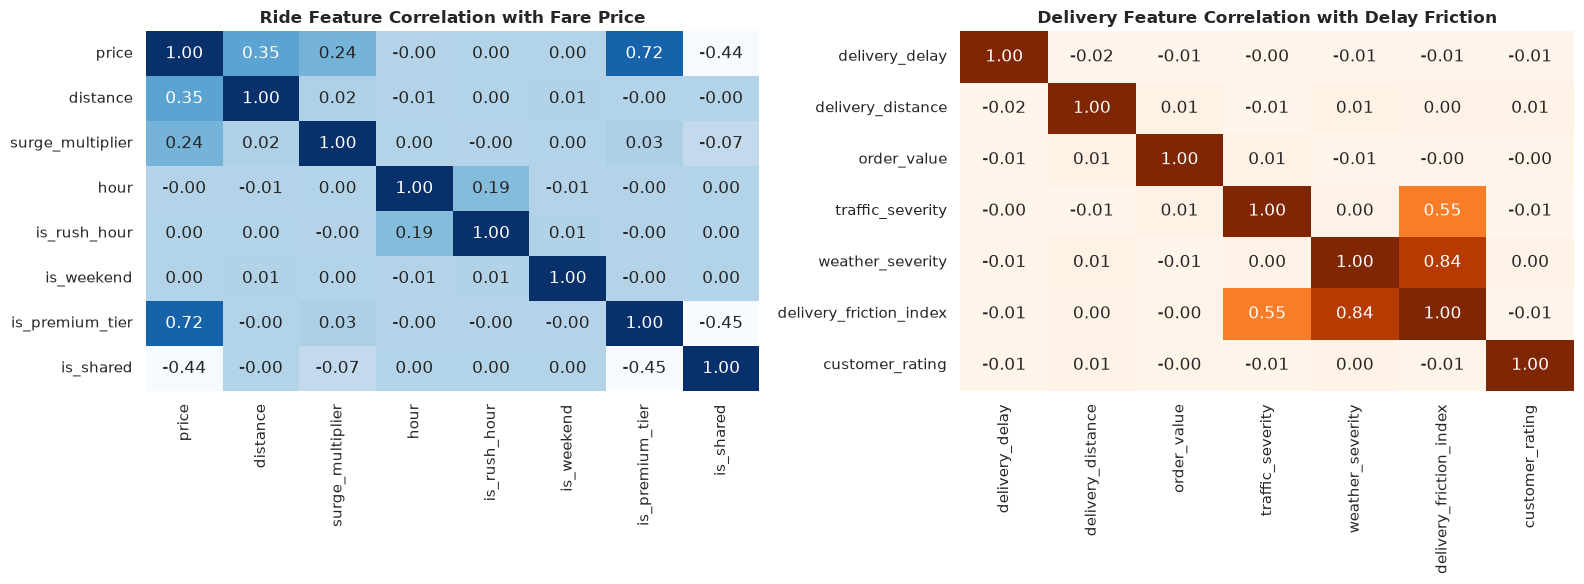

In [5]:
# 5. Correlation Analysis: Feature vs. Target Dynamics
# Verify linear correlations for pricing and operational delay prediction.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ride feature correlation
ride_num_cols = ["price", "distance", "surge_multiplier", "hour", "is_rush_hour", "is_weekend", "is_premium_tier", "is_shared"]
sns.heatmap(rides[ride_num_cols].corr(), annot=True, cmap="Blues", fmt=".2f", ax=axes[0], cbar=False)
axes[0].set_title("Ride Feature Correlation with Fare Price", fontsize=12, fontweight="bold")

# Delivery feature correlation
deliv_num_cols = ["delivery_delay", "delivery_distance", "order_value", "traffic_severity", "weather_severity", "delivery_friction_index", "customer_rating"]
sns.heatmap(deliv[deliv_num_cols].corr(), annot=True, cmap="Oranges", fmt=".2f", ax=axes[1], cbar=False)
axes[1].set_title("Delivery Feature Correlation with Delay Friction", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


In [6]:
# 6. Export cleaned and engineered features to disk
# Save processed CSVs in data/processed for use in model training (Notebook 04).
ride_features = rides[[
    "distance", "surge_multiplier", "hour", "day_of_week", 
    "is_weekend", "is_rush_hour", "is_late_night", 
    "is_premium_tier", "is_shared", "cab_type", "price"
]].copy()

delivery_features = deliv[[
    "delivery_distance", "order_value", "traffic_severity", 
    "weather_severity", "is_small_basket", "is_long_distance", 
    "delivery_friction_index", "delivery_delay"
]].copy()

ride_features.to_csv("../data/processed/ride_features.csv", index=False)
delivery_features.to_csv("../data/processed/delivery_features.csv", index=False)

print(f"Saved ../data/processed/ride_features.csv: {ride_features.shape}")
print(f"Saved ../data/processed/delivery_features.csv: {delivery_features.shape}")


Saved ../data/processed/ride_features.csv: (100000, 11)
Saved ../data/processed/delivery_features.csv: (20000, 8)
